In [6]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import pickle

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [16]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)

amip_hist_models        = np.load('./data/helper/amip_hist_models.npy')
amip_piForcing_models   = np.load('./data/helper/amip_piForcing_models.npy')
historical_models       = np.load('./data/helper/historical_models.npy')

amip_hist_n_ensembles       = np.load('./data/helper/amip_hist_n_ensembles.npy')
amip_piForcing_n_ensembles  = np.load('./data/helper/amip_piForcing_n_ensembles.npy')
historical_n_ensembles      = np.load('./data/helper/historical_n_ensembles.npy')

print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)

print(n_time,n_lat,n_lon,n_flat)

amip_hist_models = ['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1']
amip_piForcing_models = ['CESM2' 'CNRM-CM6-1' 'CanESM5' 'HadGEM3-GC31-LL' 'IPSL-CM6A-LR' 'MIROC6'
 'MRI-ESM2-0' 'TaiESM1']
historical_models = ['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CESM2' 'CESM2-FV2'
 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-HR4' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'CanESM5'
 'CanESM5-CanOE' 'E3SM-1-0' 'E3SM-1-1' 'E3SM-1-1-ECA' 'EC-Earth3'
 'EC-Earth3-AerChem' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'FGOALS-g3' 'FIO-ESM-2-0' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6' 'MPI-ESM-1-2-HAM'
 'MPI-ESM1-2-HR'

In [43]:
print(amip_hist_models, amip_hist_n_ensembles)

['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1'] [ 1  3  3  3 10  1  1 10  3  4  3  1  3  5  5  3]


In [27]:
def models_with_min_ensembles(models, counts, minimum=3):
    return [
        str(model)
        for model, count in zip(models, counts)
        if count >= minimum
    ]

def model_overlap(*model_lists):
    common = set(model_lists[0]).intersection(*model_lists[1:])
    return [model for model in model_lists[0] if model in common]

amip_hist_models_3plus = models_with_min_ensembles(
    amip_hist_models, amip_hist_n_ensembles
)

amip_piForcing_models_3plus = models_with_min_ensembles(
    amip_piForcing_models, amip_piForcing_n_ensembles
)

historical_models_3plus = models_with_min_ensembles(
    historical_models, historical_n_ensembles
)

amip_hist_amip_piForcing_overlap_3plus = model_overlap(
    amip_hist_models_3plus,
    amip_piForcing_models_3plus,
)

amip_hist_historical_overlap_3plus = model_overlap(
    amip_hist_models_3plus,
    historical_models_3plus,
)

amip_piForcing_historical_overlap_3plus = model_overlap(
    amip_piForcing_models_3plus,
    historical_models_3plus,
)

In [7]:
with open("./data/maps_2000_2014/map_similarity.pkl", "rb") as f:
    output = pickle.load(f)

map_similarity = output["map_similarity"]
regions = output["regions"]
metric_names = output["metric_names"]

In [8]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def make_model_styles(map_similarity):
    names = sorted({
        model
        for experiments in map_similarity.values()
        for fields in experiments.values()
        for regions in fields.values()
        for model in regions
    })

    colors = plt.get_cmap("tab20").colors
    markers = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "h", "p", "*"]

    return {
        name: {
            "color": colors[i % len(colors)],
            "marker": markers[(i // len(colors)) % len(markers)]
        }
        for i, name in enumerate(names)
    }


def plot_map_similarity(
    map_similarity,
    x,
    y,
    models=None,
    model_styles=None,
    member_mode="cross",
    spread="range",
    limits=None,
    xlim=None,
    ylim=None,
    xlabel=None,
    ylabel=None,
    title=None,
    fit_line=True,
    one_to_one=False,
    legend=True,
    legend_ncol=None,
    figsize=(9, 8),
    save=None,
    show=True,
):
    def get_data(selection):
        # selection = (experiment, field, region, metric)
        # experiment: "amip_hist", "amip_piForcing", or "historical"
        # field:      "covRTi", "covTRi", or "regTiRi"
        # region:     "global", "6060", or "3030"
        # metric:     "corr", "ccc", "bias", or "rmse"
        experiment, field, region, metric = selection
        metric = metric.lower()
        block = map_similarity[experiment][field][region]
        return {
            model: np.asarray(
                np.ma.filled(values[metric], np.nan), dtype=float
            ).ravel()
            for model, values in block.items()
        }

    def selection_label(selection):
        experiment, field, region, metric = selection
        return f"{metric.upper()}: {field}, {experiment}, {region}"

    xdata = get_data(x)
    ydata = get_data(y)
    overlap = [model for model in xdata if model in ydata]

    if models is None or models in ("all", "overlap"):
        selected = overlap
    else:
        requested = list(models)
        selected = [model for model in requested if model in overlap]
        missing = [model for model in requested if model not in overlap]
        if missing:
            warnings.warn(f"Skipped models missing from one selection: {missing}")

    if not selected:
        raise ValueError("The two selections have no requested models in common.")

    model_styles = model_styles or make_model_styles(map_similarity)
    fig, ax = plt.subplots(figsize=figsize)
    summary = {}

    for model in selected:
        xv = xdata[model][np.isfinite(xdata[model])]
        yv = ydata[model][np.isfinite(ydata[model])]

        if not xv.size or not yv.size:
            continue

        xm, ym = xv.mean(), yv.mean()
        style = model_styles[model]
        color, marker = style["color"], style["marker"]

        summary[model] = {
            "x": xv,
            "y": yv,
            "x_mean": xm,
            "y_mean": ym,
            "x_min": xv.min(),
            "x_max": xv.max(),
            "y_min": yv.min(),
            "y_max": yv.max(),
        }

        if spread == "range":
            xerr = np.array([[xm - xv.min()], [xv.max() - xm]])
            yerr = np.array([[ym - yv.min()], [yv.max() - ym]])
        elif spread == "std":
            xstd = xv.std(ddof=1) if xv.size > 1 else 0
            ystd = yv.std(ddof=1) if yv.size > 1 else 0
            xerr, yerr = xstd, ystd
        elif spread is None:
            xerr = yerr = None
        else:
            raise ValueError("spread must be 'range', 'std', or None")

        if spread is not None:
            ax.errorbar(
                xm, ym, xerr=xerr, yerr=yerr,
                fmt="none", ecolor=color, elinewidth=1.4,
                capsize=3, alpha=0.55, zorder=1
            )

        if member_mode == "cross":
            ax.scatter(
                xv, np.full(xv.shape, ym),
                s=28, color=color, marker=marker,
                alpha=0.35, edgecolors="none", zorder=2
            )
            ax.scatter(
                np.full(yv.shape, xm), yv,
                s=28, color=color, marker=marker,
                alpha=0.35, edgecolors="none", zorder=2
            )
        elif member_mode == "paired":
            if xv.size == yv.size:
                ax.scatter(
                    xv, yv, s=28, color=color, marker=marker,
                    alpha=0.35, edgecolors="none", zorder=2
                )
            else:
                warnings.warn(
                    f"{model}: paired members skipped because ensemble "
                    f"counts differ ({xv.size} versus {yv.size})."
                )
        elif member_mode is not None:
            raise ValueError("member_mode must be 'cross', 'paired', or None")

        ax.scatter(
            xm, ym, s=140, color=color, marker=marker,
            edgecolors="black", linewidths=0.8,
            label=model, zorder=3
        )

    if not summary:
        raise ValueError("No finite data were available for the selected models.")

    if limits is not None:
        xlim = ylim = limits
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    fixed_xlim, fixed_ylim = ax.get_xlim(), ax.get_ylim()
    xmeans = np.array([v["x_mean"] for v in summary.values()])
    ymeans = np.array([v["y_mean"] for v in summary.values()])

    if fit_line and len(xmeans) > 1 and np.ptp(xmeans) > 0:
        reg = stats.linregress(xmeans, ymeans)
        xx = np.array(fixed_xlim)
        ax.plot(
            xx, reg.slope * xx + reg.intercept,
            color="#777777", linestyle="--",
            linewidth=1.2, alpha=0.8, zorder=0
        )
        ax.text(
            0.98, 0.98, f"R² = {reg.rvalue**2:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=12,
            bbox=dict(
                boxstyle="round", facecolor="white",
                alpha=0.85, edgecolor="gray"
            )
        )

    if one_to_one:
        lo = max(fixed_xlim[0], fixed_ylim[0])
        hi = min(fixed_xlim[1], fixed_ylim[1])
        ax.plot(
            [lo, hi], [lo, hi],
            color="black", linestyle=":",
            linewidth=1, alpha=0.5, zorder=0
        )

    ax.set_xlim(fixed_xlim)
    ax.set_ylim(fixed_ylim)
    ax.set_box_aspect(1)
    ax.set_xlabel(xlabel or selection_label(x), fontsize=13)
    ax.set_ylabel(ylabel or selection_label(y), fontsize=13)

    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", pad=14)

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.2, linewidth=0.5, zorder=0)

    if legend:
        ncol = legend_ncol or max(1, int(np.ceil(len(summary) / 22)))
        fontsize = 8 if len(summary) > 25 else 10
        ax.legend(
            bbox_to_anchor=(1.02, 1), loc="upper left",
            fontsize=fontsize, ncol=ncol,
            frameon=False, title="Model", title_fontsize=12
        )

    fig.tight_layout()

    if save:
        fig.savefig(save, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax, summary

In [42]:
amip_hist_models_3plus

['CAMS-CSM1-0',
 'CESM2',
 'CIESM',
 'CNRM-CM6-1',
 'CanESM5',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'FIO-ESM-2-0',
 'IPSL-CM6A-LR',
 'MIROC6',
 'MRI-ESM2-0',
 'TaiESM1']

In [19]:
list(amip_hist_models)

[np.str_('BCC-CSM2-MR'),
 np.str_('CAMS-CSM1-0'),
 np.str_('CESM2'),
 np.str_('CIESM'),
 np.str_('CNRM-CM6-1'),
 np.str_('CNRM-CM6-1-HR'),
 np.str_('CNRM-ESM2-1'),
 np.str_('CanESM5'),
 np.str_('FGOALS-f3-L'),
 np.str_('FGOALS-g3'),
 np.str_('FIO-ESM-2-0'),
 np.str_('IITM-ESM'),
 np.str_('IPSL-CM6A-LR'),
 np.str_('MIROC6'),
 np.str_('MRI-ESM2-0'),
 np.str_('TaiESM1')]

In [ ]:
amip_hist_models
amip_piForcing_models 
historical_models 

amip_hist_models_3plus 
amip_piForcing_models_3plus 
historical_models_3plus 
amip_hist_amip_piForcing_overlap_3plus 
amip_hist_historical_overlap_3plus 
amip_piForcing_historical_overlap_3plus 

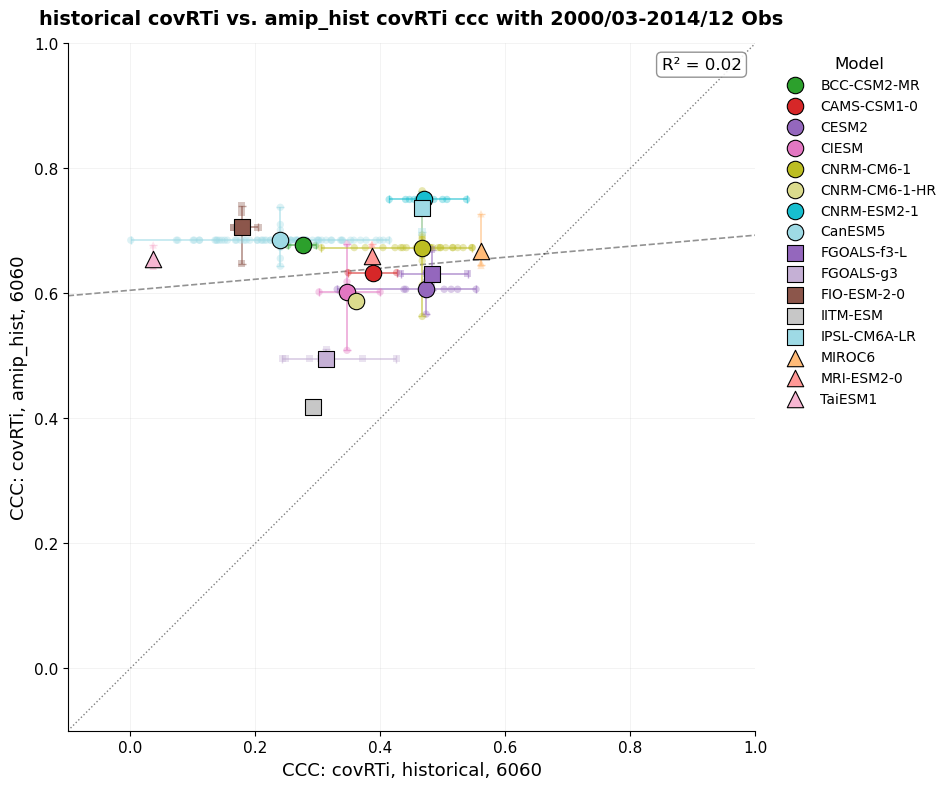

In [58]:
# selection = (experiment, field, region, metric)
# experiment: "amip_hist", "amip_piForcing", or "historical"
# field:      "covRTi", "covTRi", or "regTiRi"
# region:     "global", "6060", or "3030"
# metric:     "corr", "ccc", "bias", or "rmse"

#######
experiment_x    = "historical"
experiment_y    = "amip_hist"
field_x         = "covRTi"
field_y         = "covRTi"

domain          = "6060"
metric          = "ccc"

# models_forPlot  = amip_hist_models
models_forPlot  = None
########
sub = ""
if models_forPlot is not None:
    sub="sub"
    savepath = f"./data/maps_2000_2014/plots/{experiment_x}{field_x}_vs_{experiment_y}{field_y}_{domain}_{metric}_{sub}_amip_hist_models.svg"
else:
    savepath = f"./data/maps_2000_2014/plots/{experiment_x}{field_x}_vs_{experiment_y}{field_y}_{domain}_{metric}.svg"


fig, ax, values = plot_map_similarity(
    map_similarity,
    x=(experiment_x, field_x, domain, metric),
    y=(experiment_y, field_y, domain, metric),
    models = models_forPlot,
    limits=(-0.1, 1),
    one_to_one=True,
    title=f"{experiment_x} {field_x} vs. {experiment_y} {field_y} {metric} with 2000/03-2014/12 Obs",
    save=savepath
)

In [44]:
map_similarity['amip_hist']['covRTi']['6060']['TaiESM1']

{'corr': array([0.66012161, 0.66012161, 0.69150166]),
 'ccc': array([0.64351809, 0.64351809, 0.67753829]),
 'bias': array([-0.7209441 , -0.7209441 , -0.15896198]),
 'rmse': array([3.69065112, 3.69065112, 3.58215217])}

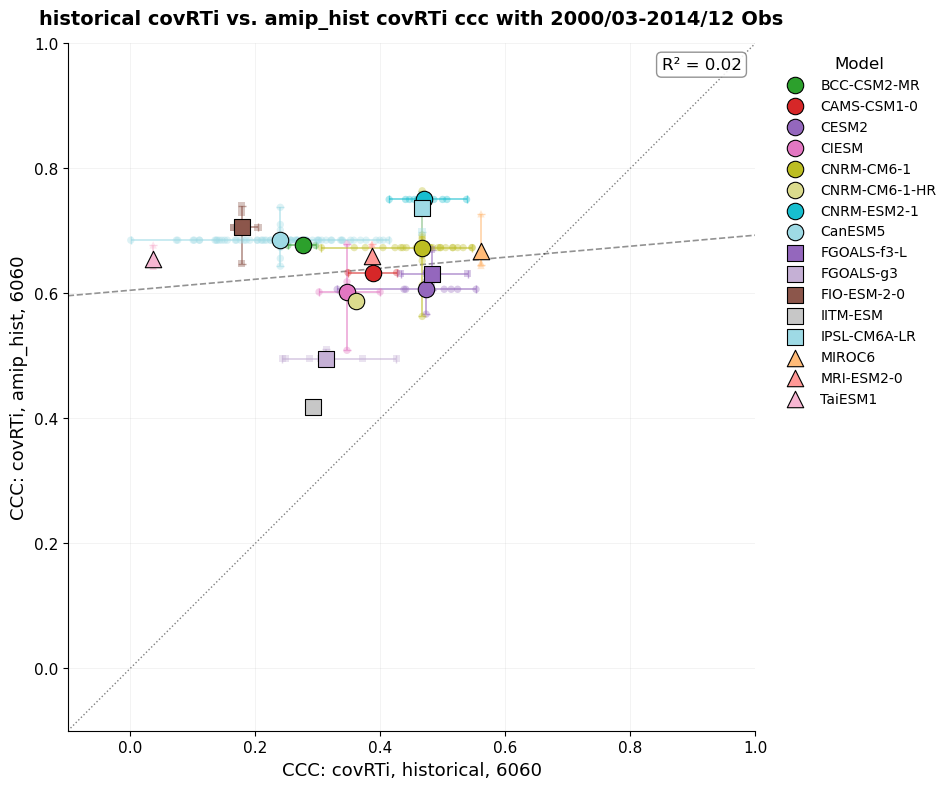

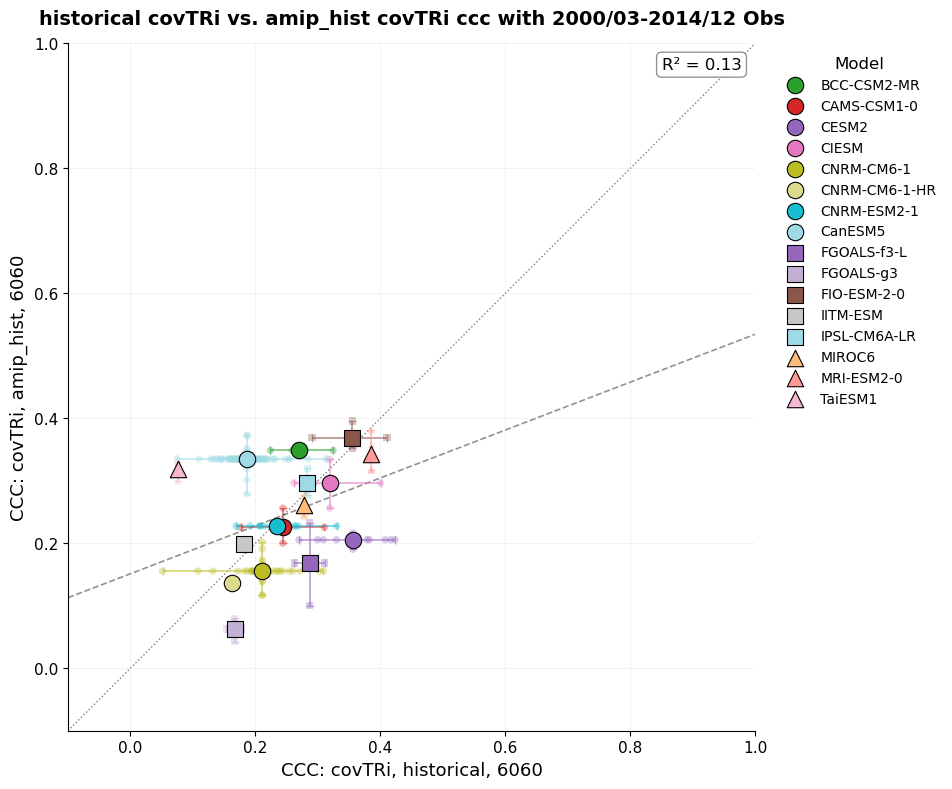

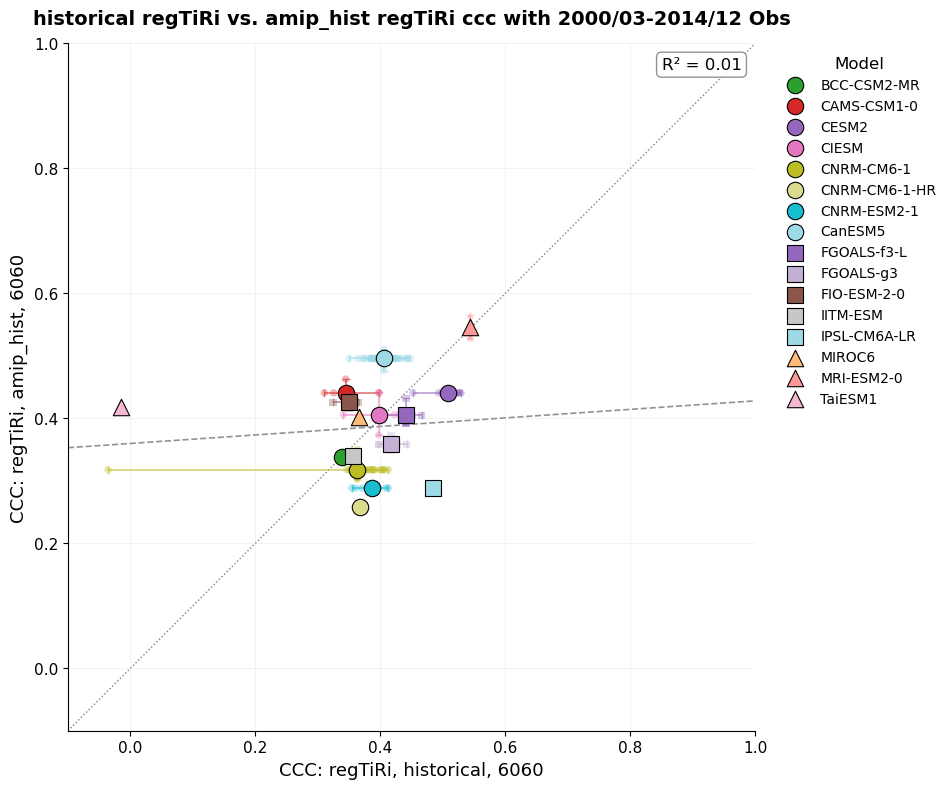

In [59]:
# selection = (experiment, field, region, metric)
# experiment: "amip_hist", "amip_piForcing", or "historical"
# field:      "covRTi", "covTRi", or "regTiRi"
# region:     "global", "6060", or "3030"
# metric:     "corr", "ccc", "bias", or "rmse"

#######
experiment_x    = "historical"
experiment_y    = "amip_hist"
field_x         = "covRTi"
field_y         = "covRTi"

domain          = "6060"
metric          = "ccc"

models_forPlot  = list(amip_hist_models)
# models_forPlot  = None
########


for field in ["covRTi", "covTRi",  "regTiRi"]:

    fig, ax, values = plot_map_similarity(
        map_similarity,
        x=(experiment_x, field, domain, metric),
        y=(experiment_y, field, domain, metric),
        models = models_forPlot,
        limits=(-0.1, 1),
        one_to_one=True,
        title=f"{experiment_x} {field} vs. {experiment_y} {field} {metric} with 2000/03-2014/12 Obs",
        save=f"./data/maps_2000_2014/plots/{experiment_x}{field}_vs_{experiment_y}{field}_{domain}_{metric}_amip_hist_models.svg"
    )